In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('C:\\Users\\Lenovo\\Videos\\kaggle\\Machine-Learning-Projects\\Complete Case Analysis In Machine Learning\\aug_test.csv')
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours
0,32403,city_41,0.827,Male,Has relevent experience,Full time course,Graduate,STEM,9,<10,NaN,1,21
1,9858,city_103,0.920,Female,Has relevent experience,no_enrollment,Graduate,STEM,5,NaN,Pvt Ltd,1,98
2,31806,city_21,0.624,Male,No relevent experience,no_enrollment,High School,NaN,<1,NaN,Pvt Ltd,never,15
3,27385,city_13,0.827,Male,Has relevent experience,no_enrollment,Masters,STEM,11,10/49,Pvt Ltd,1,39
4,27724,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,10000+,Pvt Ltd,>4,72


In [ ]:
(df.isnull().mean()*100).sort_values(ascending=False) 

company_type              29.779239
company_size              29.215594
gender                    23.860968
major_discipline          14.654767
education_level            2.442461
last_new_job               1.878816
enrolled_university        1.456083
experience                 0.234852
enrollee_id                0.000000
relevent_experience        0.000000
city_development_index     0.000000
city                       0.000000
training_hours             0.000000
dtype: float64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2129 entries, 0 to 2128
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             2129 non-null   int64  
 1   city                    2129 non-null   object 
 2   city_development_index  2129 non-null   float64
 3   gender                  1621 non-null   object 
 4   relevent_experience     2129 non-null   object 
 5   enrolled_university     2098 non-null   object 
 6   education_level         2077 non-null   object 
 7   major_discipline        1817 non-null   object 
 8   experience              2124 non-null   object 
 9   company_size            1507 non-null   object 
 10  company_type            1495 non-null   object 
 11  last_new_job            2089 non-null   object 
 12  training_hours          2129 non-null   int64  
dtypes: float64(1), int64(2), object(10)
memory usage: 216.4+ KB


In [9]:
df.describe()

,enrollee_id,city_development_index,training_hours
count,2129.000000,2129.000000,2129.000000
mean,16861.614843,0.824984,64.983091
std,9576.846029,0.125074,60.238660
min,3.000000,0.448000,1.000000
25%,8562.000000,0.698000,23.000000
50%,16816.000000,0.903000,47.000000
75%,25129.000000,0.920000,86.000000
max,33353.000000,0.949000,334.000000


In [12]:
df.describe(include='object')

,city,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job
count,2129,1621,2129,2098,2077,1817,2124,1507,1495,2089
unique,108,3,2,3,5,6,22,8,6,6
top,city_103,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,1
freq,473,1460,1524,1519,1269,1621,383,338,1141,884


In [13]:
col = [
    col for col in df.columns if df[col].isnull().mean() < 0.05 and df[col].isnull().mean() > 0
]
new_df = df[col].dropna()

In [17]:
print(df.shape)
print(new_df.shape)

print("Rows removed" , df.shape[0] - new_df.shape[0])

(2129, 13)
(2018, 4)
Rows removed 111


In [19]:
new_df.columns

Index(['enrolled_university', 'education_level', 'experience', 'last_new_job'], dtype='object')

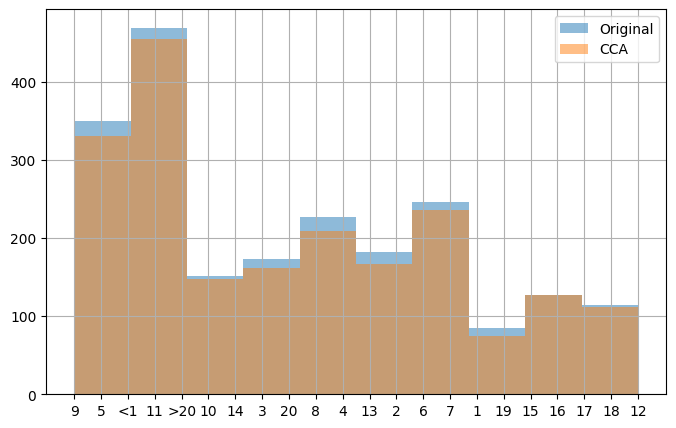

In [22]:
plt.figure(figsize=(8,5))

df['experience'].hist(alpha=0.5,label="Original")

new_df['experience'].hist(alpha=0.5,label="CCA")

plt.legend()

plt.show()

<Axes: >

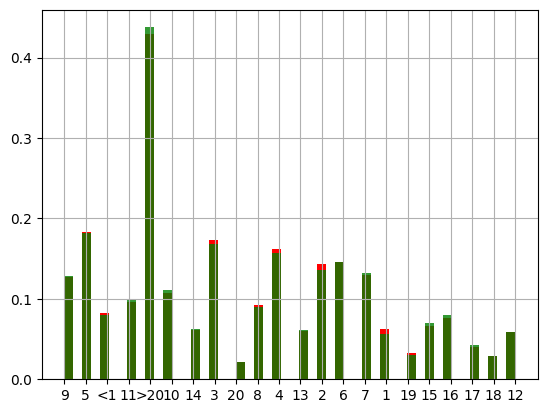

In [23]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original data
df['experience'].hist(bins=50, ax=ax, density=True, color='red')

# data after cca, the argument alpha makes the color transparent, so we can
# see the overlay of the 2 distributions
new_df['experience'].hist(bins=50, ax=ax, color='green', density=True, alpha=0.8)